# Your seed does not fix the town

**Kaggriculture draws each town shop from the same random stream it has just used to
spawn weeds — one draw per *empty unlocked tile*, on both farms. The shop that unlocks
is therefore a function of how much bare land you and your opponent happened to have
that evening, not of the episode seed alone.**

That has three consequences, and this notebook measures all three on the installed
engine rather than asserting them:

1. **A fixed `configuration["seed"]` does not fix the world.** Adding one occupied tile
   to *either* farm re-rolls every later shop unlock. Measured below on 12 seeds out of 12.
2. **The draw is worth real money, and the exposure grows as you get better.** Holding the
   seed, the opponent and every other rule constant and varying *only* the order the eight
   shops arrive in, a crop farm's season swings about 14% from worst draw to best — while
   the barely-trading built-in `starter` swings under 1%. (Section 4.)
3. **Whether your fixed-seed A/B test is controlled depends on which knob you turn.** A
   change that only reorders market orders draws the identical town on every seed and
   resolves a ten-coin effect from sixteen episodes. A change that touches how many tiles
   are occupied — labour, planting, harvesting, digging, land — re-rolls the town on *every*
   seed and buries the effect under a thousand coins of noise. Section 5, with the harness
   in Section 7.

Then there is the balance change announced on 6 August
([discussion](https://www.kaggle.com/competitions/kaggriculture/discussion/733431),
[PR #1394](https://github.com/Kaggle/kaggle-environments/pull/1394)), which switches shops
to being drawn **with replacement**. Section 6 works out what that does, exactly rather
than approximately: the all-eight-shop town every current strategy is tuned on stops being
guaranteed and becomes a **1-in-416** event, each shop type is missing from **34.4%** of
games, and **wool** — the only product in the game with a single shop demanding it — loses
**95% of its late-season demand** in the third of games with no yarn store. Repeating the
Section 4 swing measurement under the modelled new rules takes it from **14% to 36%**.

Section 7 then prices that out for the herd everyone is running. Using a market model
checked against the engine product by product, a six-sheep herd's season is worth about
**$39k with a yarn store and $11k without** — and cows, whose milk three shop types want,
earn the most in **70%** of drawn towns while sheep manage 28%. Shops unlock from day 3
onward; pastures are bought in the opening. **You commit the herd before you know the town.**

Nothing here is a leaderboard claim. It is engine behaviour, measured.


## 1. Setup, and checking the claim against the engine you actually have

Every measurement below is pinned to `kaggle-environments==1.32.5`, the release in use on
2026-08-07. That matters more than usual here: the market model has changed between minor
releases before, and the balance change discussed in Section 6 changes it again. Pinning
means the numbers in this notebook keep reproducing after the engine moves on, and Section 6
tells you what moves.

Then, rather than quote the engine source, the setup cell reads it out of the installed
package and asserts the two things the rest of the notebook depends on: that weed spawning
and the shop draw share one per-day RNG, and that weed spawning runs first. If a release
breaks that ordering the cell fails, which is the intended behaviour — a stale claim is
worse than a broken notebook.


In [1]:
# Pinned so the measurements below stay reproducible as the engine moves on.
# If this cannot run (internet off, no pip) the notebook still works -- it just measures
# whatever engine is installed, and the next cell prints which one that is.
import subprocess
import sys

PIN = "kaggle-environments==1.32.5"
try:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", PIN],
                   check=True, capture_output=True, timeout=600)
    print("pinned:", PIN)
except Exception as exc:  # noqa: BLE001 - any failure here is non-fatal by design
    print(f"could not pin ({type(exc).__name__}); measuring the preinstalled engine instead")


pinned: kaggle-environments==1.32.5


In [2]:
import contextlib
import inspect
import io
import random
import statistics as st
from collections import Counter
from fractions import Fraction
from importlib.metadata import version
from math import comb

import matplotlib.pyplot as plt

# Importing kaggle_environments prints its whole OpenSpiel game registry; keep it quiet.
with contextlib.redirect_stdout(io.StringIO()):
    from kaggle_environments import make
    import kaggle_environments.envs.kaggriculture.kaggriculture as K

plt.style.use("seaborn-v0_8-whitegrid")
BLUE, ORANGE, VERMILION, GRAY = "#0072B2", "#E69F00", "#D55E00", "#6B7280"

print("kaggle-environments:", version("kaggle-environments"))
POST_BALANCE_ENGINE = hasattr(K, "MAX_SHOP_INSTANCES")
print("engine already has the with-replacement shop draw:", POST_BALANCE_ENGINE)

src = inspect.getsource(K._end_of_day)
print("\n--- kaggriculture._end_of_day, the relevant lines ---")
for line in src.splitlines():
    if any(t in line for t in ("random.Random", "_spawn_weeds", "rng.choice", "unlocked_shops")):
        print("   ", line.strip())

assert "random.Random((seed * 1_000_003) ^ day)" in src, "per-day RNG construction changed"
assert src.index("_spawn_weeds") < src.index("rng.choice"), "weeds no longer precede the shop draw"
assert "rng.random()" in inspect.getsource(K._spawn_weeds)
print("\nOK: one per-day RNG, weeds consume it first, the shop draw takes what is left.")


kaggle-environments: 1.32.5
engine already has the with-replacement shop draw: False

--- kaggriculture._end_of_day, the relevant lines ---
    rng = random.Random((seed * 1_000_003) ^ day)
    _spawn_weeds(farm, board_size, weed_chance, rng)
    remaining = [s for s in SHOPS if s not in town["unlocked_shops"]]
    choice = rng.choice(sorted(remaining))
    town["unlocked_shops"].append(choice)

OK: one per-day RNG, weeds consume it first, the shop draw takes what is left.


## 2. The mechanism

`_spawn_weeds` calls `rng.random()` exactly once for every tile that is `None` — an empty
tile inside an unlocked quadrant. `"LOCKED"` tiles and any tile holding a plant, a weed, a
coop or a pasture cost nothing. It is called for player 0 and then for player 1, off the
same stream, and only afterwards does the shop unlock take its draw.

So the position in the stream at which the shop is chosen equals

```
(player 0's empty unlocked tiles) + (player 1's empty unlocked tiles)
```

on that evening. First, a check on the counting, then the consequence in pure RNG terms:
how often does shifting the stream by a single draw change which shop comes out?


In [3]:
# The counting: only None tiles consume a draw.
probe_farm = {"tiles": [[None, "LOCKED"], [{"kind": "WEED"}, None]]}
calls = {"n": 0}


class CountingRng:
    def random(self):
        calls["n"] += 1
        return 1.0  # never below weed_chance, so nothing on the board changes


K._spawn_weeds(probe_farm, 2, 0.005, CountingRng())
print(f"4 tiles, of which 2 are empty -> {calls['n']} rng.random() calls")
assert calls["n"] == 2

SHOP_TYPES = sorted(K.SHOPS)


def shop_drawn_after(seed, day, n_draws, remaining=None):
    """Reproduce the engine's draw for a given position in the per-day stream."""
    rng = random.Random((seed * 1_000_003) ^ day)
    for _ in range(n_draws):
        rng.random()
    return rng.choice(sorted(remaining if remaining is not None else SHOP_TYPES))


N_SEEDS = 2000
changed = sum(
    1 for s in range(N_SEEDS)
    if shop_drawn_after(s, 2, 48) != shop_drawn_after(s, 2, 49)
)
print(f"\nOne extra bare tile anywhere on either farm changes the day-3 shop in "
      f"{changed}/{N_SEEDS} seeds = {changed / N_SEEDS * 100:.1f}%")
clean = (len(SHOP_TYPES) - 1) / len(SHOP_TYPES) * 100
print(f"(a fully independent re-roll would change it {clean:.1f}% of the time, "
      f"so this is close to one)")


4 tiles, of which 2 are empty -> 2 rng.random() calls

One extra bare tile anywhere on either farm changes the day-3 shop in 1306/2000 seeds = 65.3%
(a fully independent re-roll would change it 87.5% of the time, so this is close to one)


## 3. It is not just your own farm: the opponent re-rolls your town

The cell above is arithmetic about a random number generator. This one is a real episode.

Player 0 plays the built-in `starter` agent both times, on the same seed. The opponent
differs by **one tile and nothing else that can touch the market**:

* `idle` passes for all 720 turns — 25 empty tiles.
* `idle_plus_one_tile` buys a single carrot seed, plants it, never waters it and never
  sells anything — the plant dies into a weed that first night and occupies its tile for
  the rest of the season, leaving 24 empty tiles.

Seeds are bought from unlimited supply at a fixed price and are not part of market
inventory, so that carrot never touches a price. Neither opponent ever sells.

To make sure player 0 really is the constant, its every action is recorded and the two
runs are compared turn by turn. **Same seed, same 720 actions, different bank.**


In [4]:
def idle(obs):
    return {"farmer": ["PASS"], "hands": [], "market": []}


def idle_plus_one_tile(obs):
    step = obs.get("step", 0)
    seeds = (obs.get("private", {}) or {}).get("seeds", {})
    if step == 0:
        return {"farmer": ["PASS"], "hands": [], "market": [["BUY_SEED", "CARROT", 1]]}
    if step == 1 and seeds.get("CARROT", 0) > 0:
        return {"farmer": ["PLANT", "CARROT"], "hands": [], "market": []}
    return {"farmer": ["PASS"], "hands": [], "market": []}


def play(agents, seed, steps=720, ctx=None):
    def run():
        env = make("kaggriculture", configuration={"episodeSteps": steps, "seed": seed})
        env.run(agents)
        last = env.steps[-1]
        return {
            "p0": last[0]["reward"],
            "p1": last[1]["reward"],
            "shops": list(last[0]["observation"]["town"]["unlocked_shops"]),
        }

    if ctx is None:
        return run()
    with ctx:
        return run()


def recording(policy):
    """Wrap an agent so we can prove afterwards that it played the same game."""
    log = []

    def wrapped(obs):
        action = policy(obs)
        log.append(repr(action))
        return action

    wrapped.log = log
    return wrapped


rows = []
for seed in range(12):
    rec_a, rec_b = recording(K.starter_agent), recording(K.starter_agent)
    a = play([rec_a, idle], seed)
    b = play([rec_b, idle_plus_one_tile], seed)
    rows.append((seed, a["p0"], b["p0"], a["shops"] == b["shops"], rec_a.log == rec_b.log))

print(f"{'seed':>5} {'vs idle':>10} {'vs idle+1 tile':>16} {'delta':>8}   same town?  same play?")
for seed, m_a, m_b, same_town, same_play in rows:
    print(f"{seed:>5} {m_a:>10.0f} {m_b:>16.0f} {m_b - m_a:>+8.0f}   "
          f"{str(same_town):<11} {same_play}")

n_same_town = sum(1 for r in rows if r[3])
n_same_play = sum(1 for r in rows if r[4])
n_moved = sum(1 for r in rows if r[1] != r[2])
print(f"\nplayer 0 played the identical action sequence: {n_same_play}/{len(rows)} seeds")
print(f"identical shop schedule:                      {n_same_town}/{len(rows)} seeds")
print(f"player 0's bank changed anyway:               {n_moved}/{len(rows)} seeds")
print("\nFirst seed, side by side:")
print("  vs idle          :", play(["starter", idle], 0)["shops"])
print("  vs idle+one tile :", play(["starter", idle_plus_one_tile], 0)["shops"])


 seed    vs idle   vs idle+1 tile    delta   same town?  same play?
    0       3509             3499      -10   False       True
    1       3491             3495       +4   False       True
    2       3511             3507       -4   False       True
    3       3487             3503      +16   False       True
    4       3509             3487      -22   False       True
    5       3487             3495       +8   False       True
    6       3485             3503      +18   False       True
    7       3501             3495       -6   False       True
    8       3499             3509      +10   False       True
    9       3514             3504      -10   False       True
   10       3487             3514      +27   False       True
   11       3512             3489      -23   False       True

player 0 played the identical action sequence: 12/12 seeds
identical shop schedule:                      0/12 seeds
player 0's bank changed anyway:               12/12 seeds

First seed, 

The `starter` agent farms a single tile and banks about $3,500, so the swing here is small
in absolute terms. It is not the size that matters in this section, it is that the size is
**not zero**: the seed did not fix the world. The next section measures what the town is
worth to a farm that actually trades.


## 4. What the draw is worth

To measure the town we need an agent whose income depends on it. The one below is
deliberately ordinary — a greedy job scheduler on a crop farm, no animals, no cleverness —
but it is chosen so that its produce (strawberry, carrot, wheat) is what the shops actually
demand. It banks several times the built-in starter and nothing like the top of the ladder,
which is fine: it is a measuring stick, not a submission.


In [5]:
CROP_INFO = {
    "WHEAT": {"seed": 10, "max_yield_day": 4, "ongoing": False},
    "CARROT": {"seed": 20, "max_yield_day": 3, "ongoing": False},
    "STRAWBERRY": {"seed": 100, "max_yield_day": 10, "ongoing": True},
}
SELL_BATCH = {"STRAWBERRY": 3, "CARROT": 6, "WHEAT": 8}
SEED_BUFFER = {"STRAWBERRY": 2, "CARROT": 2, "WHEAT": 2}
ROW_CROP = ["STRAWBERRY", "STRAWBERRY", "CARROT", "CARROT", "WHEAT"]
TARGET_HANDS = 5


def _jobs(farm, seeds, day):
    """Everything the farm needs done, as (priority, tile, op)."""
    jobs = []
    for y, row in enumerate(farm["tiles"]):
        for x, tile in enumerate(row):
            if tile == "LOCKED":
                continue
            if tile is None:
                crop = ROW_CROP[y % 5]
                if seeds.get(crop, 0) > 0:
                    jobs.append((40, (x, y), ("PLANT", crop)))
                continue
            kind = tile.get("kind")
            if kind == "WEED":
                jobs.append((20, (x, y), ("DIG",)))
            elif kind == "PLANT":
                info = CROP_INFO.get(tile["crop"])
                age = day - tile["planted_day"]
                ready = tile["yield_units"] > 0 and (
                    info is None or info["ongoing"] or age >= info["max_yield_day"]
                )
                if ready:
                    jobs.append((60, (x, y), ("HARVEST",)))
                if not tile["watered_today"]:
                    urgent = tile["consecutive_unwatered"] >= 1
                    jobs.append((99 if urgent else 70, (x, y), ("WATER",)))
    return jobs


def _step_towards(pos, target):
    (x, y), (tx, ty) = pos, target
    if x != tx:
        return "EAST" if x < tx else "WEST"
    if y != ty:
        return "SOUTH" if y < ty else "NORTH"
    return None


def field_agent(obs):
    player = obs.get("player", 0)
    farms = obs.get("farms", [])
    if not farms or player >= len(farms):
        return {"farmer": ["PASS"], "hands": [], "market": []}
    farm = farms[player]
    private = obs.get("private", {}) or {}
    seeds = dict(private.get("seeds", {}) or {})
    shed = private.get("shed", {}) or {}
    day, hour, money = obs.get("day", 0), obs.get("hour", 0), farm["money"]
    units = [tuple(farm["farmer"])] + [tuple(h) for h in farm.get("hands", [])]
    n_hands = len(farm.get("hands", []))

    market = []
    if hour == 0:
        market += [["HIRE"]] * max(0, TARGET_HANDS - farm.get("hires_today", 0))
    for product, batch in SELL_BATCH.items():          # meter sales down the price curve
        if shed.get(product, 0) > 0:
            market.append(["SELL", product, min(batch, shed[product])])
    for crop, want in SEED_BUFFER.items():
        need, cost = want - seeds.get(crop, 0), CROP_INFO[crop]["seed"]
        if need > 0 and money >= cost * need:
            market.append(["BUY_SEED", crop, need])
            money -= cost * need
            seeds[crop] = seeds.get(crop, 0) + need
    if len(farm["unlocked_quadrants"]) < 3 and money >= 6000:
        market.append(["BUY_LAND"])
    market = market[:10]

    jobs = sorted(_jobs(farm, seeds, day), key=lambda j: -j[0])
    plant_budget, assigned, taken = dict(seeds), {}, set()
    for _, target, op in jobs:
        if target in taken:
            continue
        if op[0] == "PLANT" and plant_budget.get(op[1], 0) <= 0:
            continue
        free = [i for i in range(len(units)) if i not in assigned]
        if not free:
            break
        i = min(free, key=lambda i: abs(units[i][0] - target[0]) + abs(units[i][1] - target[1]))
        assigned[i] = (target, op)
        taken.add(target)
        if op[0] == "PLANT":
            plant_budget[op[1]] -= 1

    actions = []
    for i in range(len(units)):
        if i not in assigned:
            actions.append(["PASS"])
            continue
        target, op = assigned[i]
        move = _step_towards(units[i], target)
        actions.append([move] if move else list(op))
    return {"farmer": actions[0], "hands": actions[1:1 + n_hands], "market": market}


demo = play([field_agent, "starter"], seed=7)
print(f"field agent {demo['p0']:,.0f}   vs built-in starter {demo['p1']:,.0f}")


field agent 12,571   vs built-in starter 3,477


Now pin the town. `pinned_shops` overrides one thing and nothing else: the *identity* of
the shop that unlocks. Weeds still spawn from the same stream, the day still refreshes the
same way, both agents still play the same policy on the same seed. Only the order the eight
shops arrive in changes.

Twelve random orders, one fixed seed, two agents of very different trade volume. Everything
that varies below is the town.


In [6]:
_ORIGINAL_END_OF_DAY = K._end_of_day


@contextlib.contextmanager
def pinned_shops(schedule):
    """Force the k-th shop unlock of the episode to be schedule[k]."""

    def patched(state, env, day):
        town = state[0].observation.town
        before = len(town["unlocked_shops"])
        _ORIGINAL_END_OF_DAY(state, env, day)
        if len(town["unlocked_shops"]) > before and before < len(schedule):
            town["unlocked_shops"][-1] = schedule[before]

    K._end_of_day = patched
    try:
        yield
    finally:
        K._end_of_day = _ORIGINAL_END_OF_DAY


@contextlib.contextmanager
def no_shops():
    """Unlock nothing: the town centre becomes the only demand in the game."""

    def patched(state, env, day):
        town = state[0].observation.town
        before = len(town["unlocked_shops"])
        _ORIGINAL_END_OF_DAY(state, env, day)
        del town["unlocked_shops"][before:]

    K._end_of_day = patched
    try:
        yield
    finally:
        K._end_of_day = _ORIGINAL_END_OF_DAY


SEED = 7
rng = random.Random(0)
schedules = []
for _ in range(12):
    s = SHOP_TYPES[:]
    rng.shuffle(s)
    schedules.append(s)

# Two agents through the identical twelve towns: the built-in starter trades a handful of
# carrots a season, the field agent works a whole quadrant. If the town is what is moving
# the score, the one that trades more should be the one that feels it.
results = {}
for name, policy in (("starter", "starter"), ("field agent", field_agent)):
    banks = []
    for s in schedules:
        r = play([policy, "starter"], SEED, ctx=pinned_shops(s))
        assert r["shops"] == s
        banks.append(r["p0"])
    results[name] = banks

for name, banks in results.items():
    lo_, hi_, mid_ = min(banks), max(banks), st.median(banks)
    print(f"{name:>12} (seed {SEED}): median {mid_:>10,.0f}   worst {lo_:>10,.0f}   "
          f"best {hi_:>10,.0f}   spread {(hi_ - lo_) / mid_ * 100:5.1f}% of median")

# One seed could be a fluke, so repeat the field agent's twelve towns on two more.
for extra in (21, 42):
    b = [play([field_agent, "starter"], extra, ctx=pinned_shops(s))["p0"] for s in schedules]
    print(f"{'field agent':>12} (seed {extra}): median {st.median(b):>10,.0f}   "
          f"worst {min(b):>10,.0f}   best {max(b):>10,.0f}   "
          f"spread {(max(b) - min(b)) / st.median(b) * 100:5.1f}% of median")

banks = results["field agent"]
lo, hi, mid = min(banks), max(banks), st.median(banks)
empty_town = play([field_agent, "starter"], SEED, ctx=no_shops())["p0"]
print(f"\nfield agent, seed {SEED} fixed, only the shop ORDER varies, n={len(banks)}")
for bank, s in sorted(zip(banks, schedules)):
    print(f"  {bank:>9,.0f}   first three shops: {', '.join(s[:3])}")
print(f"  spread {hi - lo:,.0f} = {(hi - lo) / mid * 100:.1f}% of the median season, "
      f"standard deviation {st.stdev(banks):,.0f}")
print(f"  with no shops at all: {empty_town:,.0f} "
      f"({(mid - empty_town) / empty_town * 100:.0f}% below the median town)")


     starter (seed 7): median      3,502   worst      3,487   best      3,514   spread   0.8% of median
 field agent (seed 7): median     14,184   worst     13,165   best     15,128   spread  13.8% of median
 field agent (seed 21): median     14,222   worst     13,201   best     15,308   spread  14.8% of median
 field agent (seed 42): median     14,284   worst     13,265   best     15,228   spread  13.7% of median

field agent, seed 7 fixed, only the shop ORDER varies, n=12
     13,165   first three shops: BAKERY, SMOOTHIE_SHOP, YARN_STORE
     13,194   first three shops: PIZZA_SHOP, PET_CAFE, ICE_CREAM_SHOP
     13,603   first three shops: BRUNCH_SPOT, BAKERY, PET_CAFE
     13,881   first three shops: PET_CAFE, BRUNCH_SPOT, PIZZA_SHOP
     13,957   first three shops: ICE_CREAM_SHOP, YARN_STORE, FARMERS_MARKET
     14,126   first three shops: PET_CAFE, BRUNCH_SPOT, PIZZA_SHOP
     14,242   first three shops: ICE_CREAM_SHOP, YARN_STORE, BRUNCH_SPOT
     14,323   first three shops: BRUNC

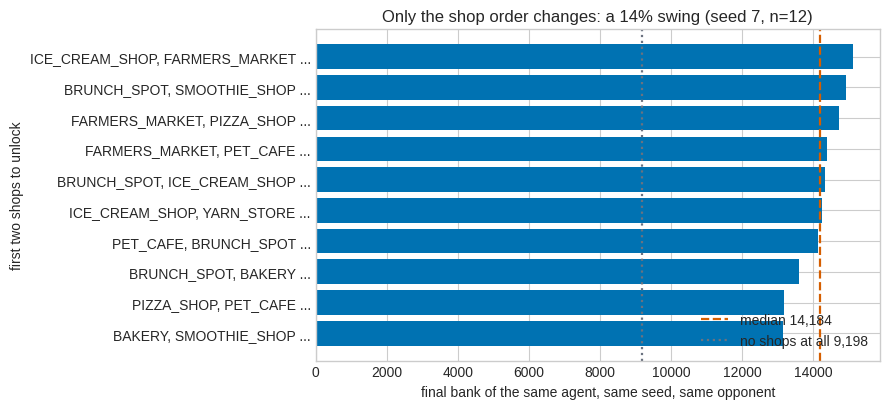

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.2))
order = sorted(range(len(banks)), key=lambda i: banks[i])
ax.barh([f"{', '.join(schedules[i][:2])} ..." for i in order],
        [banks[i] for i in order], color=BLUE)
ax.axvline(mid, color=VERMILION, linestyle="--", linewidth=1.6, label=f"median {mid:,.0f}")
ax.axvline(empty_town, color=GRAY, linestyle=":", linewidth=1.6,
           label=f"no shops at all {empty_town:,.0f}")
ax.set_xlabel("final bank of the same agent, same seed, same opponent")
ax.set_ylabel("first two shops to unlock")
ax.set_title(f"Only the shop order changes: a {(hi - lo) / mid * 100:.0f}% swing "
             f"(seed {SEED}, n={len(banks)})")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


Having a town at all is worth about half again on top of a townless season, and *which*
town you get is worth around a seventh of it. Neither is under your control, and neither is
pinned by the seed.

Note the two agents in the table above. The built-in starter sells a handful of carrots all
season and barely notices which shops arrive. The field agent works a whole quadrant and
swings by more than a tenth. **The exposure scales with how much you trade** — which means
the number that matters to a top-of-ladder farm, selling far more than either of these, is
plausibly larger than 14%, not smaller. Getting better at this game makes more of your
score depend on a draw you do not control.

A different agent shape will give a different figure again — a wool-and-milk ranch is
exposed to a different basket than a crop farm. What does not change is that the exposure
exists and that the seed does not remove it.


## 5. Which changes are safe to A/B on a fixed seed, and which are not

The mechanism says the confound arrives through *tile occupancy*. So it should matter
enormously which knob you turn, and that is testable. Two one-knob changes to the agent
above, measured the way everyone measures: same seeds, same opponent, paired differences.

* **Market-only** — strawberry sell batch, 3 units per turn instead of 4. Changes the order
  book, cannot change which tiles are occupied.
* **Labour** — five hired hands instead of four. Changes how many tiles get tended, so it
  changes how many sit bare at nightfall.

Each is run twice: on the stock engine, and with the town pinned per seed so both arms face
the same eight shops in the same order. I expected both to be contaminated. Only one is.


In [8]:
def variant(**overrides):
    """The same policy with one module-level constant swapped for the duration of a call."""
    globals_ = globals()

    def wrapped(obs):
        saved = {k: globals_[k] for k in overrides}
        globals_.update(overrides)
        try:
            return field_agent(obs)
        finally:
            globals_.update(saved)

    return wrapped


BASE = variant()
MARKET_ONLY = variant(SELL_BATCH={**SELL_BATCH, "STRAWBERRY": 4})
LABOUR = variant(TARGET_HANDS=TARGET_HANDS - 1)


def schedule_for(seed):
    r = random.Random(seed)
    s = SHOP_TYPES[:]
    r.shuffle(s)
    return s


AB_SEEDS = list(range(100, 116))
ab = {name: {"stock": [], "pinned": [], "same_town": 0}
      for name in ("market only", "labour")}

for seed in AB_SEEDS:
    sched = schedule_for(seed)
    base_stock = play([BASE, "starter"], seed)
    base_pin = play([BASE, "starter"], seed, ctx=pinned_shops(sched))["p0"]
    for name, arm in (("market only", MARKET_ONLY), ("labour", LABOUR)):
        v_stock = play([arm, "starter"], seed)
        v_pin = play([arm, "starter"], seed, ctx=pinned_shops(sched))["p0"]
        ab[name]["stock"].append(v_stock["p0"] - base_stock["p0"])
        ab[name]["pinned"].append(v_pin - base_pin)
        ab[name]["same_town"] += v_stock["shops"] == base_stock["shops"]

n = len(AB_SEEDS)
print(f"n = {n} seeds, paired differences against the same base agent\n")
for name, r in ab.items():
    sd_s, sd_p = st.stdev(r["stock"]), st.stdev(r["pinned"])
    se = sd_s / n ** 0.5
    print(f"{name}")
    print(f"  drew the SAME town as the base agent: {r['same_town']}/{n} seeds")
    print(f"  stock engine : mean {st.mean(r['stock']):+9,.0f}   sd {sd_s:9,.0f}   "
          f"95% CI [{st.mean(r['stock']) - 1.96 * se:+9,.0f}, "
          f"{st.mean(r['stock']) + 1.96 * se:+9,.0f}]")
    print(f"  town pinned  : mean {st.mean(r['pinned']):+9,.0f}   sd {sd_p:9,.0f}")
    if sd_p < sd_s:
        print(f"  -> pinning cuts the noise sd by {(1 - sd_p / sd_s) * 100:.0f}%, worth "
              f"{(sd_s / sd_p) ** 2:.1f}x the episodes")
    else:
        print("  -> pinning changes nothing here; there was nothing to pin away")
    # How many seeds would it take to call an effect of this size, at 80% power?
    effect = abs(st.mean(r["stock"]))
    if effect > 0:
        need = max(1, round((2.8 * sd_p / effect) ** 2))
        print(f"  -> calling an effect of {effect:,.0f} at 80% power takes about "
              f"{need:,} seed{'s' if need != 1 else ''} with the town pinned")
    print()


n = 16 seeds, paired differences against the same base agent

market only
  drew the SAME town as the base agent: 16/16 seeds
  stock engine : mean       -10   sd         1   95% CI [      -11,       -10]
  town pinned  : mean       -10   sd         2
  -> pinning changes nothing here; there was nothing to pin away
  -> calling an effect of 10 at 80% power takes about 1 seed with the town pinned

labour
  drew the SAME town as the base agent: 0/16 seeds
  stock engine : mean      +342   sd     1,322   95% CI [     -305,      +990]
  town pinned  : mean      +274   sd     1,074
  -> pinning cuts the noise sd by 19%, worth 1.5x the episodes
  -> calling an effect of 342 at 80% power takes about 77 seeds with the town pinned



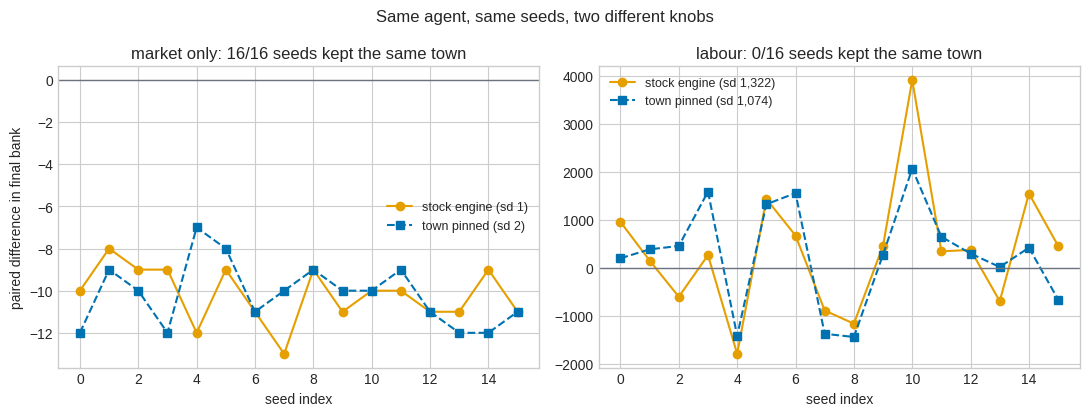

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
x = range(len(AB_SEEDS))
for axis, (name, r) in zip(axes, ab.items()):
    sd_s, sd_p = st.stdev(r["stock"]), st.stdev(r["pinned"])
    axis.plot(x, r["stock"], "o-", color=ORANGE, label=f"stock engine (sd {sd_s:,.0f})")
    axis.plot(x, r["pinned"], "s--", color=BLUE, label=f"town pinned (sd {sd_p:,.0f})")
    axis.axhline(0, color=GRAY, linewidth=1)
    axis.set_title(f"{name}: {r['same_town']}/{len(AB_SEEDS)} seeds kept the same town")
    axis.set_xlabel("seed index")
    axis.legend(loc="best", fontsize=9)
axes[0].set_ylabel("paired difference in final bank")
fig.suptitle("Same agent, same seeds, two different knobs")
plt.tight_layout()
plt.show()


The two panels are the same experiment on the same agent and the same seeds. The only
difference is which number was changed.

**The market-only knob is clean.** It cannot move a tile, so the town is identical on every
seed, stock and pinned agree exactly, and a single seed already resolves the ten-coin
effect. On a fixed seed, that experiment is a real experiment.

**The labour knob is not.** One fewer hand means fewer tiles tended, which means a different
number of bare tiles at nightfall, which re-rolls the town — on *every* seed. The paired
difference goes from a couple of coins of noise to well over a thousand, and calling the
effect at 80% power now takes dozens of seeds rather than one. Pinning the town removes part
of that and not all: the same change also perturbs the weeds and genuinely interacts with the
season, and pinning does not touch either.

So the rule is narrower and more useful than "fixed seeds are broken":

> **If the knob you are testing can change how many tiles are occupied on any evening —
> labour, planting, harvesting, digging, buying land — your fixed-seed A/B is comparing two
> different towns. If it only reorders market orders, it is not.**

Most of the interesting knobs in this game are in the first list.

This also explains why local win rates here can look decisive and mean very little. A change
that adds a few coins wins nearly every mirror match, because the two agents are otherwise
identical and the margin is a rounding error; a change worth thousands can lose a fixed-seed
comparison because it moved the shops. Neither is measuring strategy.


## 6. After the balance change

On 6 August the organisers announced two rebalances
([discussion](https://www.kaggle.com/competitions/kaggriculture/discussion/733431)). The one
that matters here, from the [diff](https://github.com/Kaggle/kaggle-environments/pull/1394):

```python
# before: sampled without replacement from the shops not yet unlocked
remaining = [s for s in SHOPS if s not in town["unlocked_shops"]]
if remaining:
    town["unlocked_shops"].append(rng.choice(sorted(remaining)))

# after: drawn WITH replacement, capped at MAX_SHOP_INSTANCES = 8
if len(town["unlocked_shops"]) < MAX_SHOP_INSTANCES:
    town["unlocked_shops"].append(rng.choice(sorted(SHOPS)))
```

Today every game ends with all eight shop types open and only the order varies. After the
change the *composition* varies too, and the arithmetic is unforgiving. None of the
following is simulated — it is counted.


In [10]:
N = 8  # MAX_SHOP_INSTANCES, and there are 8 shop types
p_absent = Fraction(N - 1, N) ** N
fact = 1
for i in range(1, N + 1):
    fact *= i
p_all = Fraction(fact, N ** N)

print("Drawing 8 shop instances with replacement from 8 types:")
print(f"  P(a given type never appears)  = (7/8)^8 = {float(p_absent) * 100:5.1f}%")
print(f"  P(all eight types appear)      = 8!/8^8  = {float(p_all) * 100:5.2f}%"
      f"   (about 1 game in {round(1 / float(p_all))})")
print(f"  E[distinct types in a town]    = {N * (1 - float(p_absent)):.2f} of 8")
print("\n  copies of one specific shop:")
for k in range(5):
    p = Fraction(comb(N, k) * (N - 1) ** (N - k), N ** N)
    print(f"    exactly {k}: {float(p) * 100:5.1f}%")

print("\nHow many shop types demand each product:")
sources = {}
for shop, items in K.SHOPS.items():
    for item in items:
        sources.setdefault(item, []).append(shop)
for item in sorted(sources):
    mark = "   <-- single source" if len(sources[item]) == 1 else ""
    print(f"  {item:<11} {len(sources[item])}{mark}")


Drawing 8 shop instances with replacement from 8 types:
  P(a given type never appears)  = (7/8)^8 =  34.4%
  P(all eight types appear)      = 8!/8^8  =  0.24%   (about 1 game in 416)
  E[distinct types in a town]    = 5.25 of 8

  copies of one specific shop:
    exactly 0:  34.4%
    exactly 1:  39.3%
    exactly 2:  19.6%
    exactly 3:   5.6%
    exactly 4:   1.0%

How many shop types demand each product:
  CARROT      2
  EGG         2
  MILK        3
  STRAWBERRY  4
  TOMATO      2
  WHEAT       5
  WOOL        1   <-- single source


**Wool is the only product in the game with exactly one shop behind it.** The yarn store is
a single-product shop, so it eats double on every tick; lose it and wool has nothing left
but the town centre — which the same PR cuts from up to 4 units every 12 turns to 1 unit
every 24.

That matters because sheep are in the farm shape currently reported at the top of the
ladder — around eight cows and six sheep, per the public replay tracker in
[What the Top Farms Do](https://www.kaggle.com/code/cjlcjlcjl/kaggriculture-what-the-top-farms-do-a-live-meta)
(that composition is their measurement of the ladder, not mine; everything below is mine).
Here is what such a herd's wool market looks like before and after.


In [11]:
TURNS_PER_DAY, SHOP_TICK = 24, 4
shop_ticks_per_day = TURNS_PER_DAY // SHOP_TICK          # unchanged by the PR
yarn_per_day = shop_ticks_per_day * 2                    # single-product shops eat 2x

print(f"one yarn store eats {yarn_per_day} wool/day ({shop_ticks_per_day} ticks/day, 2 per tick)\n")
print(f"{'late-season wool demand (day 25)':<48} {'units/day':>10}")
old = yarn_per_day + (TURNS_PER_DAY // 12) * 4           # town centre: 4x after day 20
print(f"{'today, yarn store guaranteed':<48} {old:>10}")
new_with = yarn_per_day + (TURNS_PER_DAY // 24) * 1      # town centre: flat 1, every 24 turns
print(f"{'after the change, one yarn store drawn':<48} {new_with:>10}")
new_without = (TURNS_PER_DAY // 24) * 1
print(f"{'after the change, no yarn store drawn':<48} {new_without:>10}"
      f"   <- {float(p_absent) * 100:.1f}% of games")
print(f"\nthat is a {(1 - new_without / old) * 100:.0f}% cut in wool demand, "
      f"in about one game in three")

# What a herd produces, and how much glut wool tolerates -- both from engine constants.
interval = K.ANIMALS["SHEEP"]["interval"]          # a sheep produces every `interval` days
per_sheep_per_day = (1 + interval) / interval      # CARE banks +1/day, paid at production
print(f"\none cared-for sheep produces {per_sheep_per_day:.2f} wool/day; six produce "
      f"{6 * per_sheep_per_day:.1f}/day")

i0 = K.MARKET_PARAMS["WOOL"]["I0"]
glut = 0
while K.market_price("WOOL", i0 + glut) > 1 and glut < 5000:
    glut += 1
print(f"wool hits the $1 floor {glut} units above its starting inventory of {i0:,}")


one yarn store eats 12 wool/day (6 ticks/day, 2 per tick)

late-season wool demand (day 25)                  units/day
today, yarn store guaranteed                             20
after the change, one yarn store drawn                   13
after the change, no yarn store drawn                     1   <- 34.4% of games

that is a 95% cut in wool demand, in about one game in three

one cared-for sheep produces 1.33 wool/day; six produce 8.0/day
wool hits the $1 floor 59 units above its starting inventory of 10,000


So six cared-for sheep clear in a single day roughly what a yarn-store-less town absorbs in
a week, and wool's glut curve is quadratic — the floor arrives fast. In about a third of
post-change games, a wool herd is farming something the town does not want.

The same reasoning applies in reverse: a town that draws three ice cream shops wants a lot
of strawberry and milk. **After this change, the shop list stops being flavour and starts
being the most important thing in the observation.** An agent that reads
`obs["town"]["unlocked_shops"]` and re-plans can chase that; a recorded action tape cannot,
because the town it was recorded in now recurs roughly once in 416 games.

Below the announced rules are modelled locally, both changes transcribed from the PR, and
the same swing measurement from Section 4 is repeated under them.


In [12]:
MAX_SHOP_INSTANCES = 8
_ORIG_TOWN_CONSUME = K._town_consume


def _town_consume_1394(env, state, step):
    obs0 = state[0].observation
    market, town, cfg = obs0.market, obs0.town, env.configuration
    shop_interval = max(1, int(K.get(cfg, "townShopSellInterval", 4)))
    centre_interval = max(1, int(K.get(cfg, "townCenterSellInterval", 24)))   # was 12
    if step % shop_interval == 0:
        for shop_name in town.get("unlocked_shops", []):
            products = K.SHOPS[shop_name]
            for item in products:
                market["inventory"][item] -= 2 if len(products) == 1 else 1
    if step % centre_interval == 0:
        for item in K.TOWN_CENTER_PRODUCTS:
            market["inventory"][item] -= 1                                   # multipliers removed
    K._refresh_prices(market)


def _end_of_day_1394(state, env, day, basket=None):
    obs0, cfg = state[0].observation, env.configuration
    board_size = int(K.get(cfg, "boardSize", 10))
    turns_per_day = max(1, int(K.get(cfg, "turnsPerDay", 24)))
    weed_chance = float(K.get(cfg, "weedSpawnChance", 0.005))
    shed_cap = int(K.get(cfg, "shedCapacity", 100))
    unlock_interval = max(1, int(K.get(cfg, "townShopUnlockInterval", 3)))
    rng = random.Random((env.info.get("seed", 0) * 1_000_003) ^ day)
    for pid, farm in enumerate(obs0.farms):
        private = state[pid].observation.private
        K._daily_refresh_plants(farm, day, turns_per_day)
        K._daily_refresh_animals(farm, day)
        K._spawn_weeds(farm, board_size, weed_chance, rng)
        K._drop_inventories_to_shed(private, shed_cap)
        farm["farmer"] = list(K._default_spawn(board_size))
        farm["hands"], farm["hires_today"] = [], 0
        private["inventories"] = [{}]
    town = obs0.town
    if (day + 1) > 0 and (day + 1) % unlock_interval == 0:
        if len(town["unlocked_shops"]) < MAX_SHOP_INSTANCES:
            k = len(town["unlocked_shops"])
            drawn = rng.choice(sorted(K.SHOPS))
            town["unlocked_shops"].append(basket[k] if basket and k < len(basket) else drawn)


@contextlib.contextmanager
def balance_change(basket=None):
    K._end_of_day = lambda s, e, d: _end_of_day_1394(s, e, d, basket)
    K._town_consume = _town_consume_1394
    try:
        yield
    finally:
        K._end_of_day, K._town_consume = _ORIGINAL_END_OF_DAY, _ORIG_TOWN_CONSUME


rng = random.Random(1)
baskets = [[rng.choice(SHOP_TYPES) for _ in range(8)] for _ in range(12)]
new_banks = []
for basket in baskets:
    r = play([field_agent, "starter"], SEED, ctx=balance_change(basket))
    assert r["shops"] == basket
    new_banks.append(r["p0"])
    print(f"  {r['p0']:>9,.0f}   {Counter(basket).most_common(2)}")

n_lo, n_hi, n_mid = min(new_banks), max(new_banks), st.median(new_banks)
print(f"\nunder the modelled new rules, seed {SEED}, only the town varies, n={len(new_banks)}")
print(f"  worst {n_lo:,.0f}   median {n_mid:,.0f}   best {n_hi:,.0f}")
print(f"  spread {(n_hi - n_lo) / n_mid * 100:.1f}% of the median "
      f"(today, same measurement: {(hi - lo) / mid * 100:.1f}%)")
print("\nThis models an unmerged pull request read on 2026-08-07, not the shipped engine.")
print("Re-run it against the release before betting anything on the number.")


     14,856   [('YARN_STORE', 3), ('BRUNCH_SPOT', 2)]
     13,564   [('YARN_STORE', 2), ('BAKERY', 2)]
     13,668   [('BAKERY', 4), ('PET_CAFE', 1)]
     13,893   [('ICE_CREAM_SHOP', 3), ('SMOOTHIE_SHOP', 2)]
     12,926   [('ICE_CREAM_SHOP', 2), ('PIZZA_SHOP', 1)]
     14,635   [('PET_CAFE', 3), ('FARMERS_MARKET', 1)]
     11,800   [('SMOOTHIE_SHOP', 3), ('YARN_STORE', 2)]
     11,852   [('PIZZA_SHOP', 3), ('BRUNCH_SPOT', 2)]
     10,017   [('YARN_STORE', 2), ('BAKERY', 2)]
     13,620   [('ICE_CREAM_SHOP', 3), ('PIZZA_SHOP', 2)]
     13,220   [('BAKERY', 2), ('SMOOTHIE_SHOP', 2)]
     12,568   [('PIZZA_SHOP', 3), ('SMOOTHIE_SHOP', 2)]

under the modelled new rules, seed 7, only the town varies, n=12
  worst 10,017   median 13,392   best 14,856
  spread 36.1% of the median (today, same measurement: 13.8%)

This models an unmerged pull request read on 2026-08-07, not the shipped engine.
Re-run it against the release before betting anything on the number.


## 7. So what should you farm?

Everything so far has been about measurement. This section is about the decision, because
the arithmetic in Section 6 has a direct answer in it.

Pricing a season needs only the market, so it does not need an agent — but it does need the
model to be right. The cell below builds a single-product market and checks it against the
engine the only way that is unambiguous: with both players passing, nothing is ever sold,
so inventory moves purely by town consumption. If the model reproduces the engine's final
inventory for all nine products, the demand arithmetic is correct.


In [13]:
SEASON_DAYS, SHOP_TICK, UNLOCK_INTERVAL = 30, 4, 3


def shop_demand(active, item):
    n = 0
    for shop in active:
        products = K.SHOPS[shop]
        if item in products:
            n += 2 if len(products) == 1 else 1   # single-product shops eat double
    return n


def centre_demand(item, day, *, new_rules):
    if item not in K.TOWN_CENTER_PRODUCTS:
        return 0
    if new_rules:
        return 1
    return 4 if day >= 20 else (2 if day >= 10 else 1)


def run_market(item, schedule, per_day=0.0, first_day=0, *, new_rules=False):
    """Sell `per_day` units a day from `first_day`, spread evenly across the day.

    Returns (season revenue, final inventory). With per_day=0 this is the town alone.
    """
    inv = K.MARKET_PARAMS[item]["I0"]
    centre_interval = 24 if new_rules else 12
    revenue, carry = 0.0, 0.0
    for step in range(SEASON_DAYS * 24):
        day = step // 24
        if per_day and day >= first_day:
            carry += per_day / 24
            while carry >= 1:                     # orders fill before the town consumes
                price = K.market_price(item, inv)
                revenue += price
                if price > 1:                     # the floor is sticky: no inventory added
                    inv += 1
                carry -= 1
        active = schedule[:min(len(schedule), day // UNLOCK_INTERVAL)]
        if step % SHOP_TICK == 0:
            inv -= shop_demand(active, item)
        if step % centre_interval == 0:
            inv -= centre_demand(item, day, new_rules=new_rules)
    return revenue, inv


for check_seed in (0, 3, 11):
    env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": check_seed})
    env.run(["pass", "pass"])
    obs = env.steps[-1][0]["observation"]
    sched, real = list(obs["town"]["unlocked_shops"]), obs["market"]["inventory"]
    for item in K.PRODUCTS:
        assert run_market(item, sched)[1] == real[item], (check_seed, item)
    print(f"seed {check_seed}: model reproduces the engine's final inventory "
          f"for all {len(K.PRODUCTS)} products")


seed 0: model reproduces the engine's final inventory for all 9 products
seed 3: model reproduces the engine's final inventory for all 9 products
seed 11: model reproduces the engine's final inventory for all 9 products


Now price three herds. Six animals each, production rates taken from the engine's own
`ANIMALS` table assuming they are fed and cared for every day, sold in a steady metered
trickle from their first yield.

What this deliberately leaves out, because it is identical across three herds of the same
size and would only add noise to the comparison: feed (one wheat per animal per day),
the fertilizer each animal drops, and the tile each one occupies. The comparison is
therefore **per tile, not per dollar** — a goose is $300, a cow $400 and a sheep $500, which
matters against a $3,000 opening bank even though it washes out by the end of a season.

What it leaves out and should not: the opponent selling into the same market. Two sheep
herds in one game floor the wool price far faster than one, so treat the dollars below as
an upper bound and the *ratios between towns* as the result.


In [14]:
HERD, PLACED_DAY = 6, 1
herds = {}
for animal, spec in K.ANIMALS.items():
    interval = spec["interval"]
    per_animal = min(spec["max_held"], 1 + interval) / interval   # CARE banks +1/day
    herds[animal] = {
        "product": spec["product"],
        "per_day": HERD * per_animal,
        "first_day": PLACED_DAY + spec["first_yield_day"],
    }
    print(f"{HERD} {animal.lower()}: {herds[animal]['per_day']:>4.1f} "
          f"{spec['product'].lower()}/day from day {herds[animal]['first_day']}")

rng = random.Random(0)
perms = []
for _ in range(200):
    s = SHOP_TYPES[:]
    rng.shuffle(s)
    perms.append(s)
rng = random.Random(1)
baskets = [[rng.choice(SHOP_TYPES) for _ in range(8)] for _ in range(500)]

today, after = {}, {}
for animal, h in herds.items():
    today[animal] = [run_market(h["product"], s, h["per_day"], h["first_day"])[0]
                     for s in perms]
    after[animal] = [run_market(h["product"], b, h["per_day"], h["first_day"],
                                new_rules=True)[0] for b in baskets]

print(f"\n{'herd':<7}{'product':<7}{'today median':>15}{'after median':>15}{'after p10':>12}")
for animal in herds:
    a = sorted(after[animal])
    print(f"{animal.lower():<7}{herds[animal]['product'].lower():<7}"
          f"{st.median(today[animal]):>15,.0f}{st.median(a):>15,.0f}{a[len(a) // 10]:>12,.0f}")

winner = Counter(max(after, key=lambda x: after[x][i]) for i in range(len(baskets)))
print(f"\nwhich herd earns most, over {len(baskets)} drawn towns:")
for animal, k in winner.most_common():
    print(f"  {animal.lower():<7}{k:>5} = {k / len(baskets) * 100:4.1f}%")

with_yarn = [v for b, v in zip(baskets, after["SHEEP"]) if "YARN_STORE" in b]
without = [v for b, v in zip(baskets, after["SHEEP"]) if "YARN_STORE" not in b]
lost = (1 - st.median(without) / st.median(with_yarn)) * 100
print(f"\nsheep herd, with a yarn store : median ${st.median(with_yarn):>9,.0f}"
      f"  (n={len(with_yarn)})")
print(f"sheep herd, no yarn store     : median ${st.median(without):>9,.0f}"
      f"  (n={len(without)})   -> {lost:.0f}% of the season gone")


6 goose: 12.0 egg/day from day 5
6 cow:  9.0 milk/day from day 9
6 sheep:  8.0 wool/day from day 7

herd   product   today median   after median   after p10
goose  egg             13,785         12,970      12,692
cow    milk            46,691         42,366      16,032
sheep  wool            39,768         24,408      11,052

which herd earns most, over 500 drawn towns:
  cow      351 = 70.2%
  sheep    141 = 28.2%
  goose      8 =  1.6%

sheep herd, with a yarn store : median $   39,121  (n=326)
sheep herd, no yarn store     : median $   11,052  (n=174)   -> 72% of the season gone


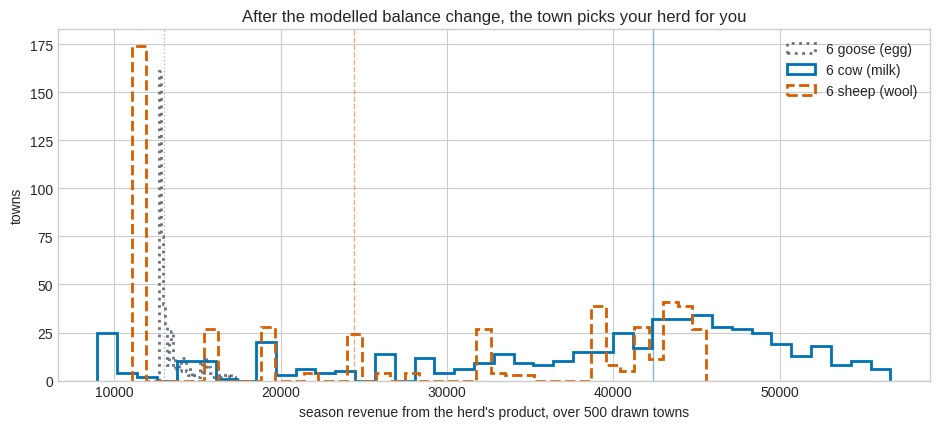

In [15]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
styles = {"GOOSE": (GRAY, ":"), "COW": (BLUE, "-"), "SHEEP": (VERMILION, "--")}
for animal, vals in after.items():
    colour, dash = styles[animal]
    ax.hist(vals, bins=40, histtype="step", linewidth=2, linestyle=dash, color=colour,
            label=f"6 {animal.lower()} ({herds[animal]['product'].lower()})")
    ax.axvline(st.median(vals), color=colour, linestyle=dash, linewidth=1, alpha=0.5)
ax.set_xlabel("season revenue from the herd's product, over 500 drawn towns")
ax.set_ylabel("towns")
ax.set_title("After the modelled balance change, the town picks your herd for you")
ax.legend()
plt.tight_layout()
plt.show()


Three things fall out of that.

**Egg is the hedge that never pays.** Its glut curve is nearly flat, so twelve eggs a day
never move the price — and the base is $50, so the season lands in the same modest place
whatever the town does. The narrowest distribution on the chart, and the lowest.

**Wool is a bet on one shop.** With a yarn store the sheep herd is competitive with cows;
without one it loses most of its season, and that happens in about a third of drawn towns.
The bimodal shape on the chart is literally the presence or absence of a single building.

**Cows are the robust choice under the new rules**, because milk is demanded by three shop
types rather than one, so the draw has to go badly wrong three times over to strand it.

The uncomfortable part is the timing. Shops unlock on days 3, 6, 9 and so on, but pastures
and animals are bought in the opening. **You commit the herd before you know the town.**
That is the concrete form of the open-loop question people have been asking in the forum:
you cannot pick the right herd in advance, so the adaptive margin is in what you sell, when
you sell it, and how much you hedge across products — not in the opening.

## 8. The harness

Two context managers, thirty lines, no dependencies. Paste them above your tuning loop so
both arms of a comparison at least face the same town.

```python
with pinned_shops(schedule_for(seed)):
    ...          # both arms see the same eight shops in the same order

with no_shops():
    ...          # the floor: what your agent earns with only the town centre buying
```

What this buys you, honestly: on the labour test in Section 5 it removed about a sixth of
the noise standard deviation. Useful, not magic. Three things it does not do:

* **It does not fix the weeds.** Player 0's weed draws are taken before player 1's, so a
  change to your own occupancy still shifts your opponent's weeds. At
  `weedSpawnChance = 0.005` that is small next to the town, but it is not zero.
* **It does not make a genuinely seed-dependent effect go away.** Most of the residual noise
  on the labour test is the change really interacting with the season differently seed by
  seed. That is signal about robustness, not something to pin out.
* **It changes the distribution you are sampling from.** Pinned results tell you which
  variant is better *in the towns you pinned*. Pin a set of schedules that covers the range,
  and after the balance change pin baskets drawn with replacement rather than permutations,
  or you will be tuning for a town that shows up once in 416 games.

The cheapest thing in this notebook is not the harness, it is the question it forces:
**can the knob I am about to test change how many tiles are occupied?** If no, a fixed seed
is enough. If yes, budget for the noise before you trust the result.

### This is not an exploit

Worth saying plainly, because the coupling sounds like one. The episode seed is scrubbed
from the configuration before agents ever see an observation
(`resolve_episode_seed` in `kaggle_environments.utils`), and it is a 31-bit draw. An agent
can therefore *shift* the shop draw by leaving a tile bare, but it has no way to know what
the shifted draw will produce — it is turning a wheel with no numbers on it. There is no
directed advantage here for either player, and nothing in this notebook should be read as
one.

What the coupling costs is measurement validity, not fairness. It is a problem for your
tuning loop, not for the ladder.

## What I did not test

* Two agent shapes are played in the engine and both are crop farms. The 14% is one agent's
  exposure, not a universal constant. What the pair shows is that the exposure tracks trade
  volume, not that any particular number is the right one. The mechanism is the claim; the
  magnitude is an illustration.
* Section 7 prices the market, not a farm. It holds each herd's production fixed and
  perfect — fed and cared every day, sold in a steady trickle — so it is an upper bound on
  what the town will pay, not a prediction of what an agent will bank. Above all it ignores
  the opponent selling into the same market, which is a real and material omission: two
  sheep herds in one game floor the wool price far faster than one. Read the *ratios*
  between towns, which is what the section is for, rather than the absolute dollars.
* No ladder or leaderboard evidence appears anywhere in this notebook. Everything is local
  episodes against the built-in `starter`, or arithmetic on the engine's own constants.
* Section 6 and Section 7's "after" numbers model an unmerged PR. If it ships changed, those
  are wrong and Sections 1-5 are not.
* I have made no submission to this competition. Take the engine reading, the harness and
  the herd arithmetic; do not take the agent as advice.

*Engine: `kaggle-environments`, version printed in Section 1. Everything above recomputes
when you run it — there are no pasted numbers in the outputs.*
